In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
#Malumot yuklab olamiz
df = pd.read_csv("https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/uzbekistan.csv", index_col=0)
df.columns = ['maydon','aholi']
df.head()

,maydon,aholi
Boʻlinishi,,
Andijon viloyati,4200.0,1899000.0
Buxoro viloyati,39400.0,1384700.0
Fargʻona viloyati,6800.0,2597000.0
Jizzax viloyati,20500.0,910500.0
Xorazm viloyati,6300.0,1200000.0


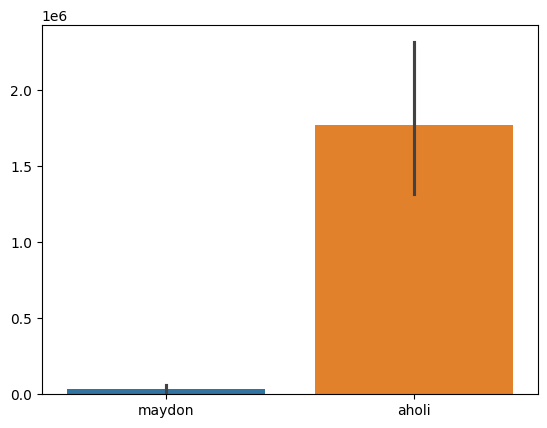

In [4]:
sns.barplot(data=df)
plt.show()

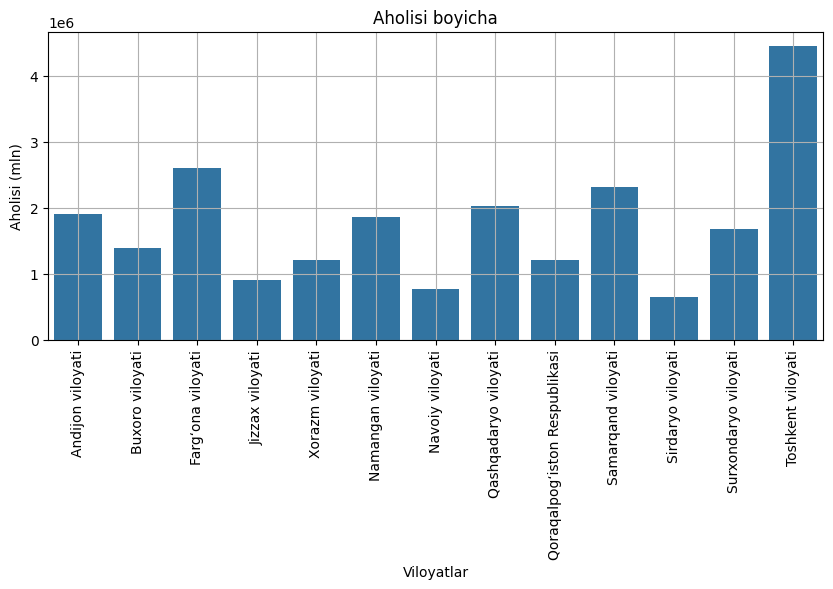

In [5]:
plt.figure(figsize=(10, 4))

plt.title('Aholisi boyicha')
plt.xlabel('Viloyatlar')
plt.ylabel('Aholisi (mln)')

sns.barplot(x=df.index, y=df['aholi'])

plt.xticks(rotation=90)
plt.grid()

plt.show()

/tmp/ipykernel_1689/3506389056.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.index, y=df['aholi'], palette='Set2')


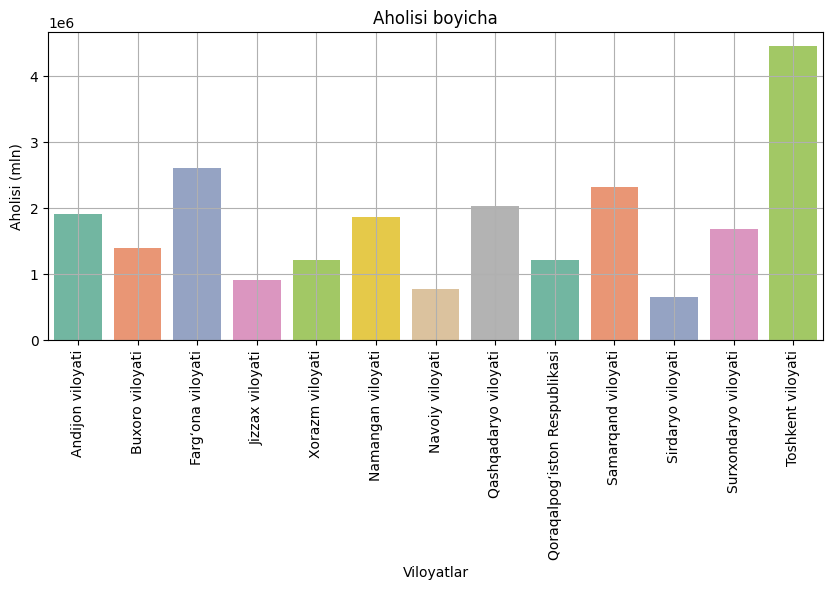

In [6]:
plt.figure(figsize=(10, 4))

plt.title('Aholisi boyicha')
plt.xlabel('Viloyatlar')
plt.ylabel('Aholisi (mln)')

sns.barplot(x=df.index, y=df['aholi'], palette='Set2')

plt.xticks(rotation=90)
plt.grid()

plt.show()

## Heatmap

Quyidagi jadvalda AQSHdagi ba'zi muzeylarga turli sanalarda tashrif buyurganlar soni saqlangan. Biz faqatgina birinchi muzey uchun qiymatlarni o'qiymi ( `usecols=[0,1]`)

In [7]:
df = pd.read_csv("https://github.com/anvarnarz/praktikum_datasets/raw/main/museum_visitors.csv", index_col=0, parse_dates=[0], usecols=[0,1])
df.head()

,Avila Adobe
Date,
2014-01-01,24778
2014-02-01,18976
2014-03-01,25231
2014-04-01,26989
2014-05-01,36883


In [8]:
df['month'] = [i.month for i in df.index]
df['year'] = [i.year for i in df.index]
df.head()

,Avila Adobe,month,year
Date,,,
2014-01-01,24778,1,2014
2014-02-01,18976,2,2014
2014-03-01,25231,3,2014
2014-04-01,26989,4,2014
2014-05-01,36883,5,2014


In [17]:
df1 = df.groupby(['month', 'year']).max()
df1.head(15)

Avila Adobe
month year             
1     2014        24778
      2015        20438
      2016        19659
      2017        18792
      2018        16265
2     2014        18976
      2015        15578
      2016        17378
      2017        14035
      2018        14718
3     2014        25231
      2015        21297
      2016        20322
      2017        20680
      2018        19001

In [18]:
df1.unstack()

Avila Adobe                                    
year         2014     2015     2016     2017     2018
month                                                
1         24778.0  20438.0  19659.0  18792.0  16265.0
2         18976.0  15578.0  17378.0  14035.0  14718.0
3         25231.0  21297.0  20322.0  20680.0  19001.0
4         26989.0  26670.0  24521.0  25234.0  18966.0
5         36883.0  34383.0  31728.0  30029.0  25173.0
6         29487.0  30569.0  23696.0  22169.0  22171.0
7         32378.0  41242.0  31689.0  30831.0  23136.0
8         37680.0  30700.0  25987.0  27009.0  20815.0
9         28473.0  20967.0  22897.0  23403.0  21020.0
10        27995.0  29764.0  25040.0  22164.0  19280.0
11        25691.0  24483.0  17760.0  17629.0  17163.0
12        18754.0  21426.0  20107.0  18339.0      NaN

In [20]:
df1.unstack(level=0)

Avila Adobe                                                        \
month          1        2        3        4        5        6        7    
year                                                                      
2014      24778.0  18976.0  25231.0  26989.0  36883.0  29487.0  32378.0   
2015      20438.0  15578.0  21297.0  26670.0  34383.0  30569.0  41242.0   
2016      19659.0  17378.0  20322.0  24521.0  31728.0  23696.0  31689.0   
2017      18792.0  14035.0  20680.0  25234.0  30029.0  22169.0  30831.0   
2018      16265.0  14718.0  19001.0  18966.0  25173.0  22171.0  23136.0   

                                                    
month       8        9        10       11       12  
year                                                
2014   37680.0  28473.0  27995.0  25691.0  18754.0  
2015   30700.0  20967.0  29764.0  24483.0  21426.0  
2016   25987.0  22897.0  25040.0  17760.0  20107.0  
2017   27009.0  23403.0  22164.0  17629.0  18339.0  
2018   20815.0  21020.0  19280.0  17163.0      NaN

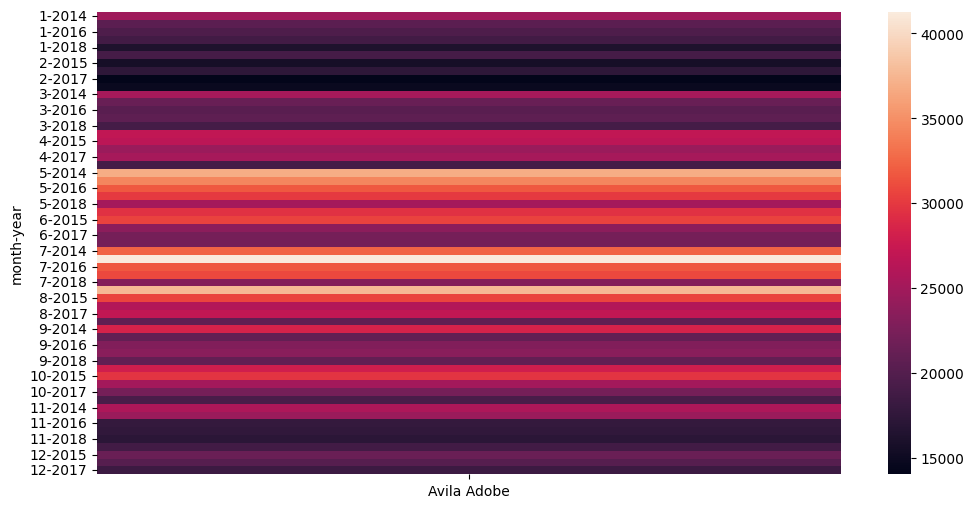

In [21]:
plt.figure(figsize=(12, 6))
sns.heatmap(df1)
plt.show()

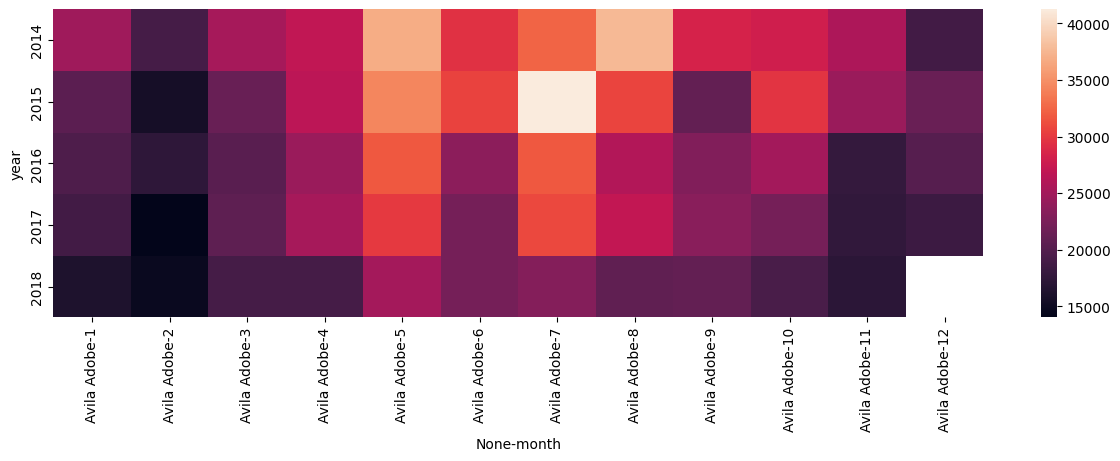

In [24]:
plt.figure(figsize=(15, 4))
sns.heatmap(df1.unstack(level=0))
plt.show()

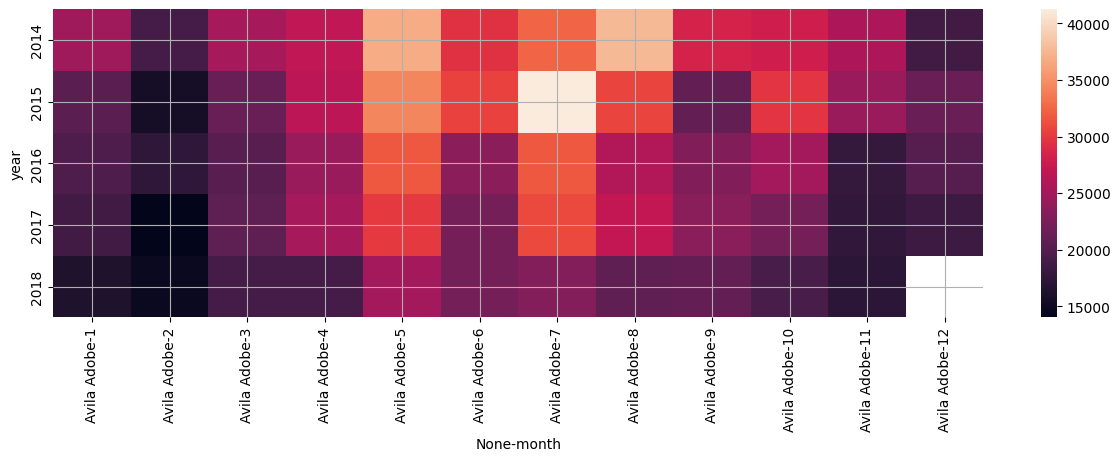

In [25]:
plt.figure(figsize=(15, 4))
sns.heatmap(df1.unstack(level=0))
plt.grid()
plt.show()

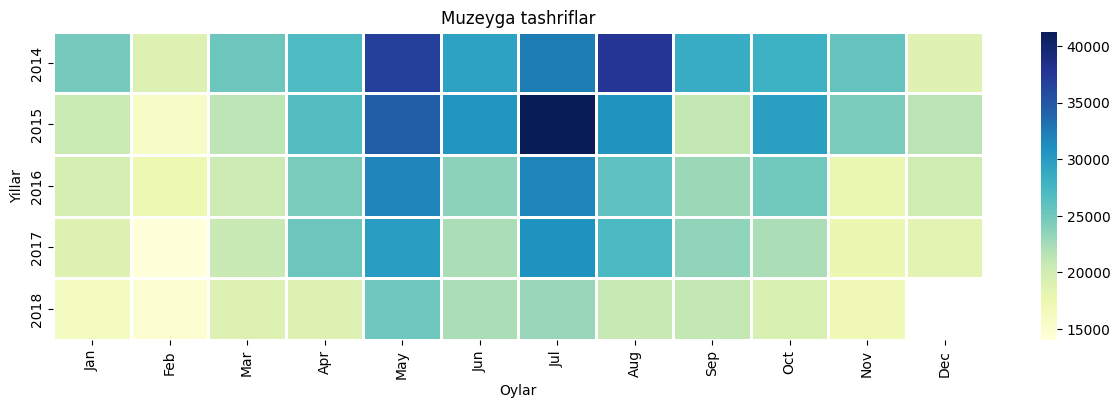

In [33]:
plt.figure(figsize=(15, 4))

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

sns.heatmap(df1.unstack(level=0), cmap='YlGnBu', linewidths=1)
plt.xticks(np.arange(12) + .5, labels=months)
plt.xlabel('Oylar')
plt.ylabel('Yillar')
plt.title('Muzeyga tashriflar')

plt.show()

In [34]:
df = pd.read_csv("https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/flight_delays.csv")
df.head()

,Month,AA,AS,B6,DL,EV,F9,HA,MQ,NK,OO,UA,US,VX,WN
0,1,6.955843,-0.320888,7.347281,-2.043847,8.537497,18.357238,3.512640,18.164974,11.398054,10.889894,6.352729,3.107457,1.420702,3.389466
1,2,7.530204,-0.782923,18.657673,5.614745,10.417236,27.424179,6.029967,21.301627,16.474466,9.588895,7.260662,7.114455,7.784410,3.501363
2,3,6.693587,-0.544731,10.741317,2.077965,6.730101,20.074855,3.468383,11.018418,10.039118,3.181693,4.892212,3.330787,5.348207,3.263341
3,4,4.931778,-3.009003,2.780105,0.083343,4.821253,12.640440,0.011022,5.131228,8.766224,3.223796,4.376092,2.660290,0.995507,2.996399
4,5,5.173878,-1.716398,-0.709019,0.149333,7.724290,13.007554,0.826426,5.466790,22.397347,4.141162,6.827695,0.681605,7.102021,5.680777


Yuqoridagi jadval turli oylarda turli aviakompaniyalarga tegishli samolyotlar  o'rtacha necha minutga kechikkani ko'rsatilgan**<sup>*</sup>** (har bir ustun bu aviakompaniya nomi qisqartmasi).

<sub>*manfiy qiymat samolyot erta kelganini anglatadi.</sub>

Biz alohida aviakompaniya uchun oyma-oy qiymatlarni ustunli grafik ko'rinishida chiqarishimiz mumkin:

/tmp/ipykernel_1689/1327616883.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['Month'], y=df['AA'], palette='Set1')


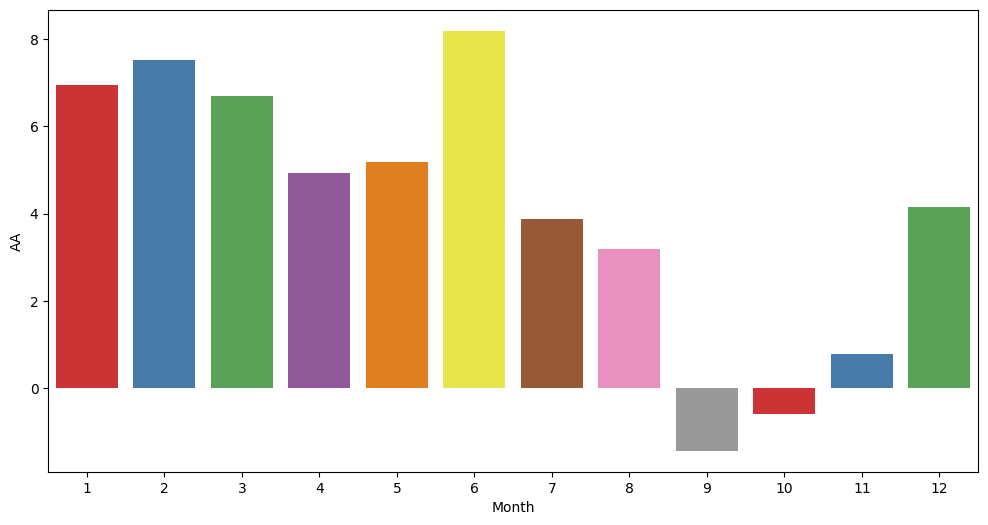

In [38]:
plt.figure(figsize=(12, 6))

sns.barplot(x=df['Month'], y=df['AA'], palette='Set1')

plt.show()

In [42]:
df_melt = df.melt(
    id_vars='Month',
    value_vars=['AA', 'MQ']
)

In [43]:
df_melt

,Month,variable,value
0,1,AA,6.955843
1,2,AA,7.530204
2,3,AA,6.693587
3,4,AA,4.931778
4,5,AA,5.173878
5,6,AA,8.191017
6,7,AA,3.870440
7,8,AA,3.193907
8,9,AA,-1.432732
9,10,AA,-0.580930


<Figure size 1200x600 with 0 Axes>

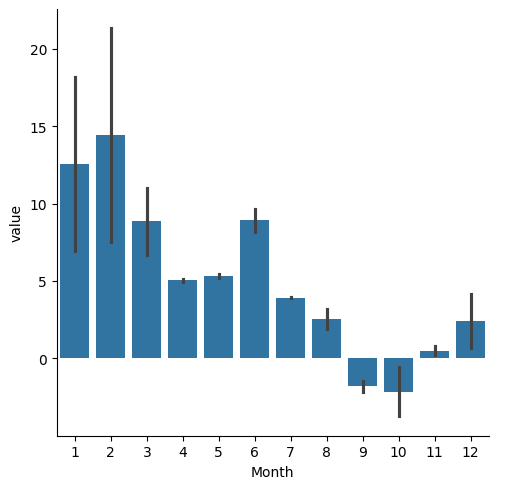

In [48]:
plt.figure(figsize=(12, 6))

sns.catplot(data=df_melt, x='Month', y='value', kind='bar')

plt.show()

<Figure size 1200x600 with 0 Axes>

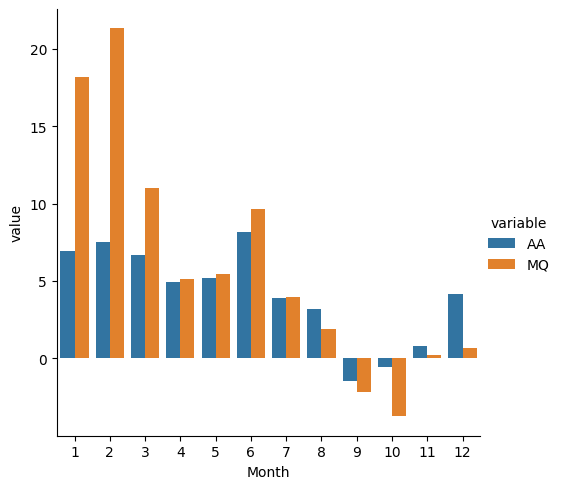

In [50]:
plt.figure(figsize=(12, 6))

sns.catplot(data=df_melt, x='Month', y='value', kind='bar', hue='variable')

plt.show()

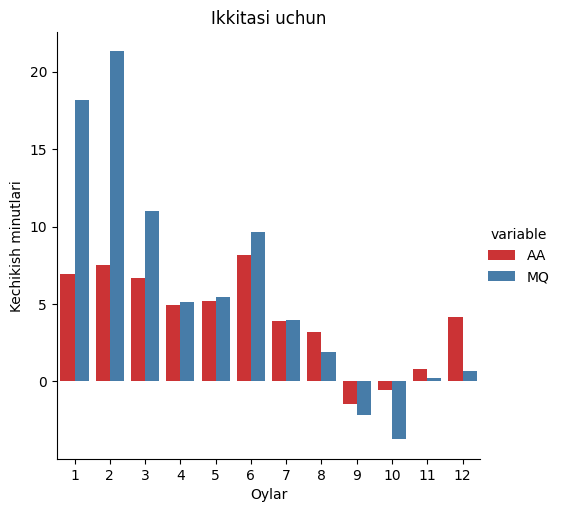

In [62]:
sns.catplot(data=df_melt, x='Month', y='value', kind='bar', hue='variable', palette='Set1')
plt.title('Ikkitasi uchun')
plt.xlabel('Oylar')
plt.ylabel('Kechikish minutlari')
plt.show()

In [63]:
data = pd.melt(df, id_vars=['Month'], value_vars=['AA', 'AS', 'DL', 'WN', 'MQ'])
data.head()

,Month,variable,value
0,1,AA,6.955843
1,2,AA,7.530204
2,3,AA,6.693587
3,4,AA,4.931778
4,5,AA,5.173878


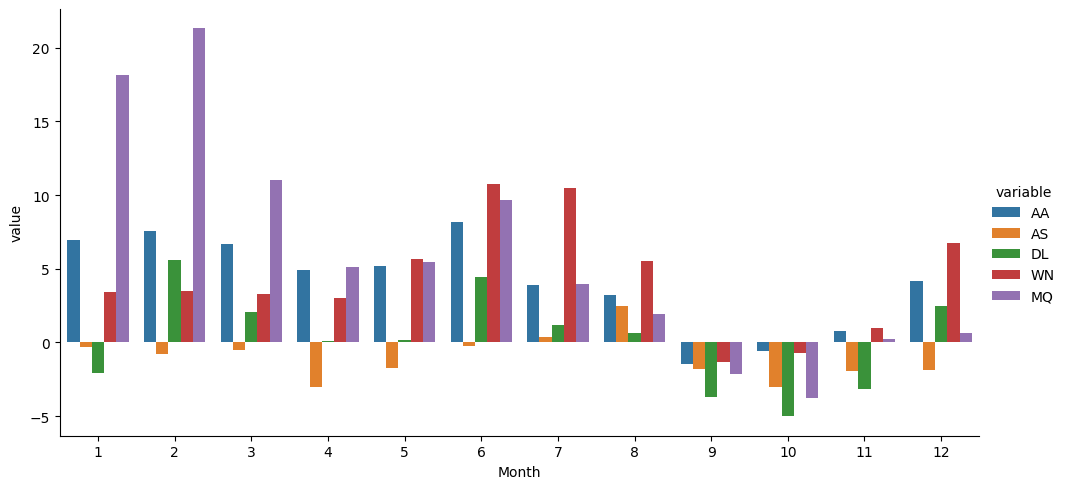

In [66]:
sns.catplot(data=data, kind="bar", x="Month", y="value", hue="variable", height=5, aspect=2)
plt.show()


In [67]:
df

,Month,AA,AS,B6,DL,EV,F9,HA,MQ,NK,OO,UA,US,VX,WN
0,1,6.955843,-0.320888,7.347281,-2.043847,8.537497,18.357238,3.512640,18.164974,11.398054,10.889894,6.352729,3.107457,1.420702,3.389466
1,2,7.530204,-0.782923,18.657673,5.614745,10.417236,27.424179,6.029967,21.301627,16.474466,9.588895,7.260662,7.114455,7.784410,3.501363
2,3,6.693587,-0.544731,10.741317,2.077965,6.730101,20.074855,3.468383,11.018418,10.039118,3.181693,4.892212,3.330787,5.348207,3.263341
3,4,4.931778,-3.009003,2.780105,0.083343,4.821253,12.640440,0.011022,5.131228,8.766224,3.223796,4.376092,2.660290,0.995507,2.996399
4,5,5.173878,-1.716398,-0.709019,0.149333,7.724290,13.007554,0.826426,5.466790,22.397347,4.141162,6.827695,0.681605,7.102021,5.680777
5,6,8.191017,-0.220621,5.047155,4.419594,13.952793,19.712951,0.882786,9.639323,35.561501,8.338477,16.932663,5.766296,5.779415,10.743462
6,7,3.870440,0.377408,5.841454,1.204862,6.926421,14.464543,2.001586,3.980289,14.352382,6.790333,10.262551,NaN,7.135773,10.504942
7,8,3.193907,2.503899,9.280950,0.653114,5.154422,9.175737,7.448029,1.896565,20.519018,5.606689,5.014041,NaN,5.106221,5.532108
8,9,-1.432732,-1.813800,3.539154,-3.703377,0.851062,0.978460,3.696915,-2.167268,8.000101,1.530896,-1.794265,NaN,0.070998,-1.336260
9,10,-0.580930,-2.993617,3.676787,-5.011516,2.303760,0.082127,0.467074,-3.735054,6.810736,1.750897,-2.456542,NaN,2.254278,-0.688851


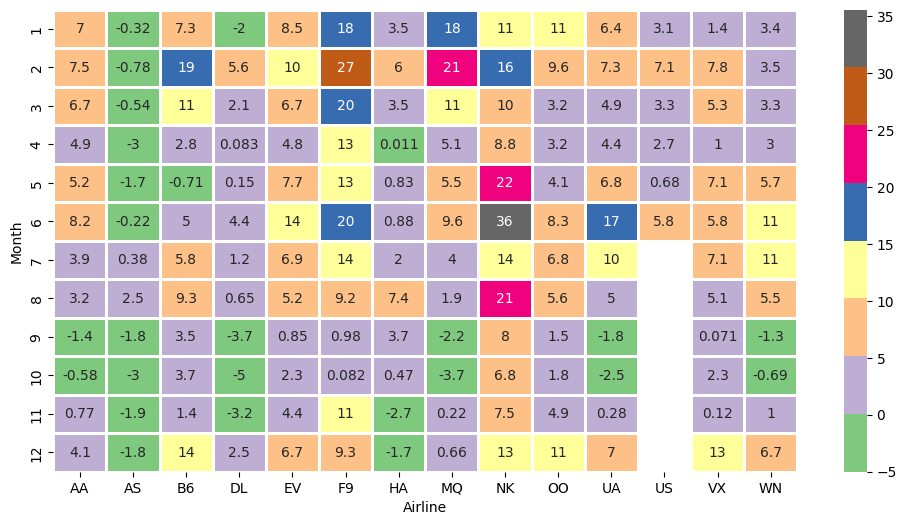

In [76]:
plt.figure(figsize=(12, 6))
sns.heatmap(data=df.set_index('Month'), cmap='Accent', linewidths=1, annot=True)
plt.xlabel('Airline')
plt.show()